# 🚗 Car Price Prediction — Linear, Ridge & Lasso Regression

**Dataset:** Used Car Sales Data  
**Goal:** Predict the price of a used car based on its features  
**Models Used:** Linear Regression → Ridge → Lasso

---

> 💡 **What will you learn?**
> - How to clean a real-world messy dataset
> - Why we use log transformation on skewed data
> - How Linear, Ridge, and Lasso Regression work
> - How to compare models and pick the best one

## Step 1 — Import Libraries

**Why?**  
Before doing anything, we load the tools we need.
- `pandas` → to load and work with data (like Excel in Python)
- `numpy` → for math operations
- `matplotlib` & `seaborn` → to make graphs
- `sklearn` → machine learning models

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 — Load the Dataset

**Why?**  
We load our CSV file into a DataFrame — think of it as opening an Excel sheet in Python.

After loading, we always check:
- How many rows and columns are there?
- What does the data look like?

In [47]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "1.04. Real-life example.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "smritisingh1997/car-salescsv",
  file_path,

)

print("First 5 records:", df.head())

C:\Users\satvi\AppData\Local\Temp\ipykernel_11788\167104996.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:            Brand    Price       Body  Mileage  EngineV Engine Type  \
0            BMW   4200.0      sedan      277      2.0      Petrol   
1  Mercedes-Benz   7900.0        van      427      2.9      Diesel   
2  Mercedes-Benz  13300.0      sedan      358      5.0         Gas   
3           Audi  23000.0  crossover      240      4.2      Petrol   
4         Toyota  18300.0  crossover      120      2.0      Petrol   

  Registration  Year         Model  
0          yes  1991           320  
1          yes  1999  Sprinter 212  
2          yes  2003         S 500  
3          yes  2007            Q7  
4          yes  2011         Rav 4  


## Step 3 — Explore the Data (EDA)

**Why?**  
Before building any model, we need to *understand* our data.

We check:
- Data types of each column
- Basic statistics (min, max, average)
- Missing values — are there any empty cells?

> ⚠️ **Real-world data is almost never clean. Always explore first!**

In [48]:
df.dtypes
df.describe()
df.isnull().sum()


Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

## Step 4 — Handle Missing Values

**Why?**  
Machine learning models cannot work with empty (NaN) values.  
We have missing values in `Price` and `EngineV`.

**Solution:** Drop rows where Price or EngineV is missing.

> 💡 `dropna()` removes rows that have missing values in the specified columns.

In [49]:
df = df.dropna(subset =['Price', 'EngineV'])
df.isnull().sum()


Brand           0
Price           0
Body            0
Mileage         0
EngineV         0
Engine Type     0
Registration    0
Year            0
Model           0
dtype: int64

## Step 5 — Remove Outliers from EngineV

**Why?**  
Look at the max value of `EngineV` — it shows **99.99!**  
No car has a 99-litre engine. These are data entry mistakes.

Outliers confuse the model and give wrong predictions.  
We keep only realistic engine sizes (≤ 10 litres).

> 💡 Always ask: *"Does this value make real-world sense?"*

In [50]:
Q1 = df['EngineV'].quantile(0.25)
Q3 = df['EngineV'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['EngineV'] >= lower) & (df['EngineV'] <= upper)]

<Axes: ylabel='EngineV'>

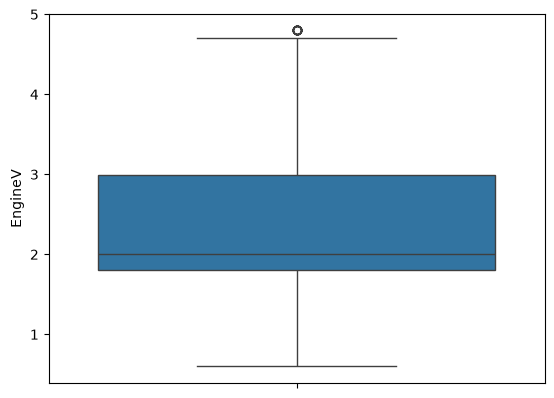

In [51]:
sns.boxplot(df['EngineV']) # TO see OUTLIERS

## Step 6 — Check Distribution of Target Variable (Price)

**Why?**  
Linear Regression works best when the target variable is **normally distributed** (bell-shaped).  

Let's plot `Price` and see its shape.

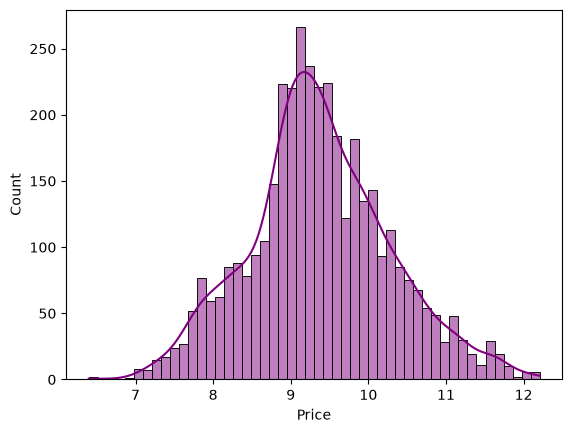

In [52]:
sns.histplot(np.log(df['Price']),kde=True,color='Purple',bins=50) #Here np.log is used to bring data or graph to the centre, This method is called Log Transformation
plt.show()

## Step 7 — Apply Log Transformation

**Why?**  
The raw `Price` is heavily right-skewed (skewness = 4.45).  
After `log(Price)`, skewness drops to ~0.24 — almost normal!

This helps our model make much better predictions.

> ⚠️ We also drop the `Model` column — it has 312 unique values (too many for simple encoding).

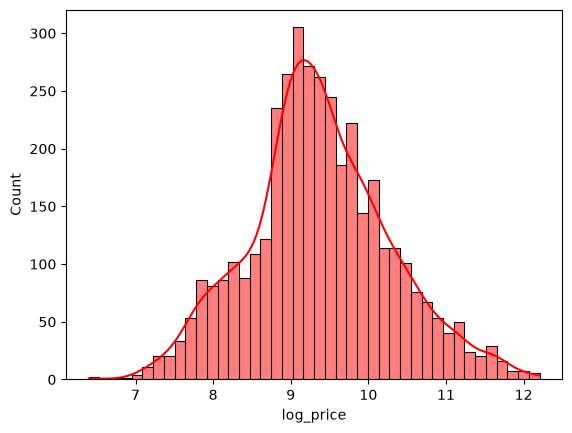

In [53]:
df['log_price'] = np.log(df['Price'])
sns.histplot(df['log_price'],color='red',kde=True)
df.drop(columns = 'Price',axis = 1, inplace=True)


## Step 8 — Encode Categorical Columns

**Why?**  
Machine learning models only understand **numbers**, not text like 'BMW' or 'Diesel'.

We use **Label Encoding** to convert text categories into numbers.

| Text | Encoded |
|------|---------|
| Audi | 0 |
| BMW  | 1 |
| Toyota | 2 |

> 💡 `LabelEncoder` assigns a unique number to each category automatically.

In [54]:
# Label encoding is a method which is used to conver text into numbers by assigning reccurent text or alphabets with numbers.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_col = df.select_dtypes(include= 'object').columns #Selects all column
for col in cat_col:
    df[col] = le.fit_transform(df[col])
df

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Model,log_price
0,1,3,277,2.0,3,1,1991,18,8.342840
1,2,5,427,2.9,0,1,1999,238,8.974618
3,0,0,240,4.2,3,1,2007,205,10.043249
4,5,0,120,2.0,3,1,2011,208,9.814656
6,1,3,438,2.0,1,1,1997,18,8.716044
...,...,...,...,...,...,...,...,...,...
4339,5,3,35,1.6,3,1,2014,104,9.792556
4340,2,3,9,3.0,0,1,2014,214,11.736069
4341,1,3,1,3.5,3,1,1999,37,8.779557
4342,1,3,194,2.0,3,1,1985,31,8.987197


## Step 9 — Correlation Heatmap

**Why?**  
A heatmap shows how strongly each feature is related to `log_price`.

- Value close to **+1** → strong positive relationship (feature goes up, price goes up)
- Value close to **-1** → strong negative relationship (feature goes up, price goes down)
- Value close to **0** → weak/no relationship

> 💡 This helps us understand which features are most important for prediction.

<Axes: >

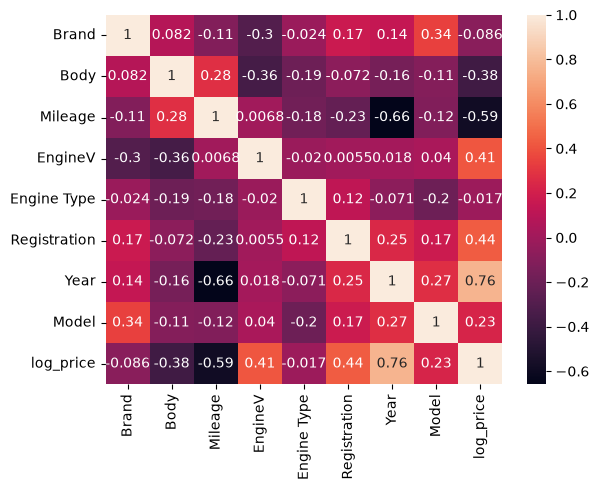

In [55]:
sns.heatmap(df.corr(),annot=True)

## Step 10 — Split Data into Train and Test Sets

**Why?**  
We train the model on one part of the data, and test it on a *different* part it has never seen.

This tells us how well the model performs on **new, unseen data** — which is the real goal!

| Split | Purpose |
|-------|---------|
| 80% Train | Model learns from this |
| 20% Test  | We evaluate model here |

> 💡 `random_state=42` ensures same split every time you run the code.

In [56]:
X = df.drop(columns=['log_price'],axis=1)
y = df['log_price']

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (3081, 8)
X_test shape: (771, 8)
y_train shape: (3081,)
y_test shape: (771,)


## Step 11 — Linear Regression

**Why start here?**  
Linear Regression is the simplest and most foundational regression model.

It finds the best straight line (or plane in multiple dimensions) that fits the data.

**Formula:**  
`Price = b0 + b1×Year + b2×Mileage + b3×EngineV + ...`

In [58]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [59]:
y_predict = reg.predict(X_test)
y_predict[ :10]

array([ 8.41629556,  9.82416114,  7.91917525, 10.37007165,  8.90153043,
        9.79268681,  9.51749202,  7.85038957, 10.11759594,  9.33977415])

In [60]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_predict
}
)
compare.head(10)

,Actual,Predicted
3624,8.839277,8.416296
516,9.841612,9.824161
330,8.160518,7.919175
4272,10.275051,10.370072
1890,8.699515,8.901530
2595,9.998798,9.792687
935,9.581904,9.517492
2395,7.600402,7.850390
680,11.194097,10.117596
2576,9.024011,9.339774


In [61]:
from sklearn.metrics import r2_score
r2_score(y_test, y_predict)

0.8192929923966753

## Step 12 — Ridge Regression

**Why Ridge?**  
Ridge is Linear Regression with a **penalty** added.

When we have many features, some coefficients can get very large — this causes **overfitting** (model memorizes training data but fails on new data).

Ridge **shrinks** large coefficients without removing any feature completely.

In [62]:
from sklearn.linear_model import Ridge
clf = Ridge()
clf.fit(X_train, y_train)

Ridge()

In [63]:
y_predict = clf.predict(X_test)
y_predict[ :10]

array([ 8.41969932,  9.82422703,  7.91901139, 10.36959817,  8.90158625,
        9.79240761,  9.51701837,  7.85299745, 10.11755323,  9.33861648])

In [64]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_predict
}
)
compare.head(10)

,Actual,Predicted
3624,8.839277,8.419699
516,9.841612,9.824227
330,8.160518,7.919011
4272,10.275051,10.369598
1890,8.699515,8.901586
2595,9.998798,9.792408
935,9.581904,9.517018
2395,7.600402,7.852997
680,11.194097,10.117553
2576,9.024011,9.338616


In [65]:
from sklearn.metrics import r2_score
r2_score(y_test, y_predict)

0.8193215538581734

## Step 13 — Lasso Regression

**Why Lasso?**  
Lasso is similar to Ridge but with one key difference:

Lasso can make some feature coefficients exactly **zero** — meaning it **removes** unimportant features automatically!

This is called **automatic feature selection** — very useful when you have many features and don't know which ones matter.

In [66]:
from sklearn import linear_model
cf = linear_model.Lasso()
cf.fit(X_train,y_train)

Lasso()

In [67]:
y_predict = cf.predict(X_test)
y_predict[:10]

array([ 9.08255913,  9.81557853,  9.14376913,  9.58925917,  9.4031876 ,
        9.48398386,  9.34700926,  8.24864373, 10.19506697,  8.79310298])

In [68]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predict': y_predict
})
compare.head(10)

,Actual,Predict
3624,8.839277,9.082559
516,9.841612,9.815579
330,8.160518,9.143769
4272,10.275051,9.589259
1890,8.699515,9.403188
2595,9.998798,9.483984
935,9.581904,9.347009
2395,7.600402,8.248644
680,11.194097,10.195067
2576,9.024011,8.793103


In [70]:
r2_score(y_test,y_predict)

0.5367512342433822

## Step 14 — Compare All Three Models

**Why compare?**  
No single model is always the best. We compare R² and RMSE to choose the winner.

- **Higher R²** = Better (closer to 1.0 is ideal)
- **Lower RMSE** = Better (smaller error is better)

In [71]:
from sklearn.metrics import mean_squared_error

# Linear Regression Metrics
reg_y_predict = reg.predict(X_test)
reg_r2 = r2_score(y_test, reg_y_predict)
reg_rmse = np.sqrt(mean_squared_error(y_test, reg_y_predict))

# Ridge Regression Metrics
clf_y_predict = clf.predict(X_test)
clf_r2 = r2_score(y_test, clf_y_predict)
clf_rmse = np.sqrt(mean_squared_error(y_test, clf_y_predict))

# Lasso Regression Metrics
cf_y_predict = cf.predict(X_test)
cf_r2 = r2_score(y_test, cf_y_predict)
cf_rmse = np.sqrt(mean_squared_error(y_test, cf_y_predict))

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [reg_r2, clf_r2, cf_r2],
    'RMSE': [reg_rmse, clf_rmse, cf_rmse]
})

display(comparison_df.set_index('Model'))

,R2 Score,RMSE
Model,,
Linear Regression,0.819293,0.385861
Ridge Regression,0.819322,0.385830
Lasso Regression,0.536751,0.617803


## Step 15 — Actual vs Predicted Plot

**Why?**  
Numbers alone don't tell the full story. This plot shows visually how close our predictions are to the actual prices.

- If points lie **on the red diagonal line** → perfect predictions
- Points **scattered away** from the line → prediction errors


<function matplotlib.pyplot.show(close=None, block=None)>

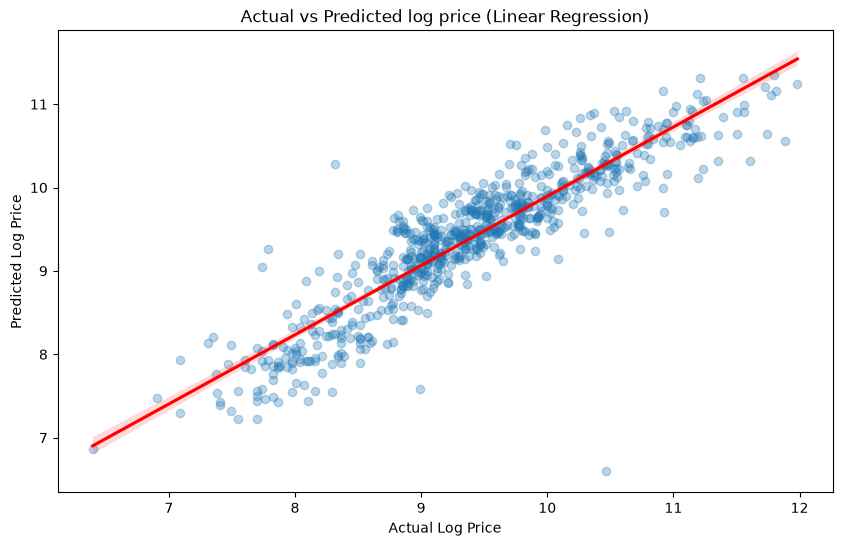

In [72]:
plt.figure(figsize=(10,6))
sns.regplot(x=y_test,y=reg_y_predict,scatter_kws={'alpha':0.3},line_kws={'color':'red'})
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Actual vs Predicted log price (Linear Regression)')
plt.show

## Step 16 - Save the Model

In [74]:
import joblib

joblib.dump(reg, 'linear_regression_model.pkl')
print("Linear Regression model saved as 'linear_regression_model.pkl'")

Linear Regression model saved as 'linear_regression_model.pkl'
